<a href="https://colab.research.google.com/github/IrineuBovoJunior398/Pos-em-IA/blob/main/AUTOENCODERS_PR%C3%81TICA_CORRETISSIMO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import fashion_mnist
from keras.layers import Dense, Input, Activation, Dropout
from keras.models import Model
from keras.models import Sequential

In [2]:
# Carregando o conjunto de dados MNIST
(x_train, y_train), (x_test, y_test) = (x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

#yn = y_train.to_numpy()
print(y_train.max())

# Normalizando os valores dos pixels para o intervalo [0, 1]
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

# Transformando as imagens em vetores unidimensionais (784 pixels)
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

# Aplicação de ruído nos dados e armazenando e variáveis acessórias
noise_factor = 0.3
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

#print(len(x_train))
#print(x_train.shape[1:])
#print(np.prod(x_train.shape[1:]))
print(x_train.shape)
print(x_test.shape)

#print(x_train.view)
print(y_train)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
9
(60000, 784)
(10000, 784)
[9 0 0 ... 3 0 5]


In [3]:
# Definindo a dimensão da representação codificada
n_latent = 120

# Criando o modelo do autoencoder
model = Sequential()
model.add(Dense(128, input_shape=(784,), activation="relu"))
model.add(Dense(300, activation="relu"))
model.add(Dense(n_latent, activation="relu"))
model.add(Dense(300, activation="relu"))
model.add(Dense(784, activation="sigmoid"))

# Compilando o modelo
model.compile(optimizer='adam', loss='binary_crossentropy')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# Treinando o autoencoder
model.fit(x_train, x_train, epochs=30, batch_size=256, shuffle=True, validation_data=(x_test, x_test))

# Codificando e decodificando as imagens de teste sem ruído
encoded_imgs = model.predict(x_test)

Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - loss: 0.3549 - val_loss: 0.3088
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.2992 - val_loss: 0.2956
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.2903 - val_loss: 0.2891
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - loss: 0.2850 - val_loss: 0.2857
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - loss: 0.2815 - val_loss: 0.2823
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - loss: 0.2791 - val_loss: 0.2827
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.2771 - val_loss: 0.2783
Epoch 8/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.2756 - val_loss: 0.2772
Epoch 9/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.2742 - val_loss: 0.2770
Epoch 10/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.2732 - val_loss: 0.2754
Epoch 11/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.2723 - val_loss: 0.2740
Epoch 12/30
235/235 ━━━━━━━━━━━━━━━━

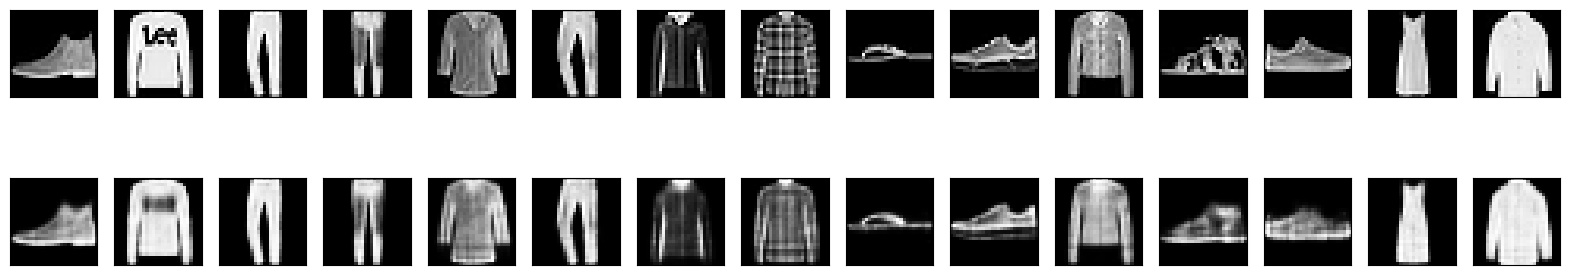

In [5]:
# Visualizando algumas imagens originais sem ruído e reconstruídas
n = 15
plt.figure(figsize=(20, 4))
for i in range(n):
    # Imagem original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Imagem reconstruída
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(encoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

In [6]:
# Codificando e decodificando as imagens de teste com ruído
encoded_imgs = model.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


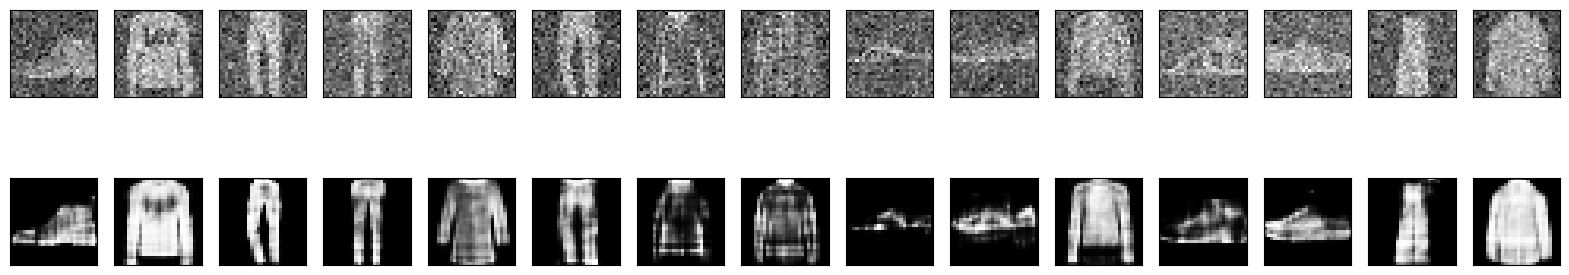

In [7]:
# Visualizando algumas imagens originais com ruído e reconstruídas
n = 15
plt.figure(figsize=(20, 4))
for i in range(n):
    # Imagem original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Imagem reconstruída
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(encoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

In [8]:
batch_size = 128
hidden_units = 256
dropout = 0.45
input_size = x_train.shape[1]
num_labels = len(np.unique(y_train))

# model is a 3-layer MLP with ReLU and dropout after each layer
model2 = Sequential()
model2.add(Dense(hidden_units, input_dim=input_size))
model2.add(Activation('relu'))
#model2.add(Dropout(dropout))
model2.add(Dense(hidden_units))
model2.add(Activation('relu'))
#model2.add(Dropout(dropout))
model2.add(Dense(num_labels))
model2.add(Activation('softmax'))

model2.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [9]:
model2.fit(x_train, y_train, epochs=50, batch_size=batch_size)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8202 - loss: 0.5116
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8683 - loss: 0.3618
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8815 - loss: 0.3237
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8896 - loss: 0.2989
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8955 - loss: 0.2824
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9008 - loss: 0.2678
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9053 - loss: 0.2540
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9100 - loss: 0.2416
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9125 - loss: 0.2317
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9155 - loss: 0.2234
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9200 - loss: 0.2145
Epoch 12/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/st

In [10]:
loss, acc = model2.evaluate(x_test, y_test, batch_size=batch_size)
print("\nTeste de Acurácia Classificação sem Ruído: %.1f%%" % (100.0 * acc))
loss, acc = model2.evaluate(x_test_noisy, y_test, batch_size=batch_size)
print("\nTeste de Acurácia Classificação com Ruído: %.1f%%" % (100.0 * acc))
loss, acc = model2.evaluate(encoded_imgs, y_test, batch_size=batch_size)
print("\nTeste de Acurácia Classificação das Imagens Recuperadas do Ruído: %.1f%%" % (100.0 * acc))

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8942 - loss: 0.5702

Teste de Acurácia Classificação sem Ruído: 89.4%
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7490 - loss: 2.4152

Teste de Acurácia Classificação com Ruído: 74.9%
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7917 - loss: 1.3607

Teste de Acurácia Classificação das Imagens Recuperadas do Ruído: 79.2%
